# Daily Demand Forecasting Using ARIMA

## Objective

The objective of this project is to analyze historical daily demand data, identify important time-series patterns, build an ARIMA forecasting model, evaluate its performance, and generate a 30-day demand forecast.

## Research Question

Can historical daily demand patterns be used to build an effective ARIMA forecasting model for predicting future demand?

## Hypothesis

Historical daily demand contains patterns that can be modeled using ARIMA. After making the demand series stationary, the ARIMA model will be able to produce useful forecasts for future demand.

## Import Libraries

The following Python libraries are used for data manipulation, visualization, time-series decomposition, stationarity testing, ARIMA modeling, and forecast evaluation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error

## Load the Daily Demand Data

The daily demand dataset is loaded into a pandas DataFrame. The date column will be converted to datetime format so that the observations can be analyzed in chronological order.

In [2]:
# Load the dataset

df = pd.read_csv("../data/daily-demand-series.csv")

print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (30, 4)

Column names:
['date', 'demand', 'marketing_event', 'holiday']

First 5 rows:


,date,demand,marketing_event,holiday
0,2026-06-01,118,0,0
1,2026-06-02,121,0,0
2,2026-06-03,125,0,0
3,2026-06-04,123,0,0
4,2026-06-05,137,1,0


## Prepare the Time-Series Data

The date column is converted to datetime format and the data is sorted chronologically. The date is then used as the time-series index. The demand variable is selected as the main forecasting target, and the dataset is checked for missing values.

In [3]:
# Prepare the time-series data

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")
df = df.set_index("date")

print("Date range:", df.index.min(), "to", df.index.max())

print("\nMissing values:")
print(df.isnull().sum())

print("\nPrepared data:")
display(df.head())

Date range: 2026-06-01 00:00:00 to 2026-06-30 00:00:00

Missing values:
demand             0
marketing_event    0
holiday            0
dtype: int64

Prepared data:


,demand,marketing_event,holiday
date,,,
2026-06-01,118,0,0
2026-06-02,121,0,0
2026-06-03,125,0,0
2026-06-04,123,0,0
2026-06-05,137,1,0


## Historical Daily Demand

The historical demand values are visualized over time to identify general changes and patterns in demand before applying statistical forecasting methods.

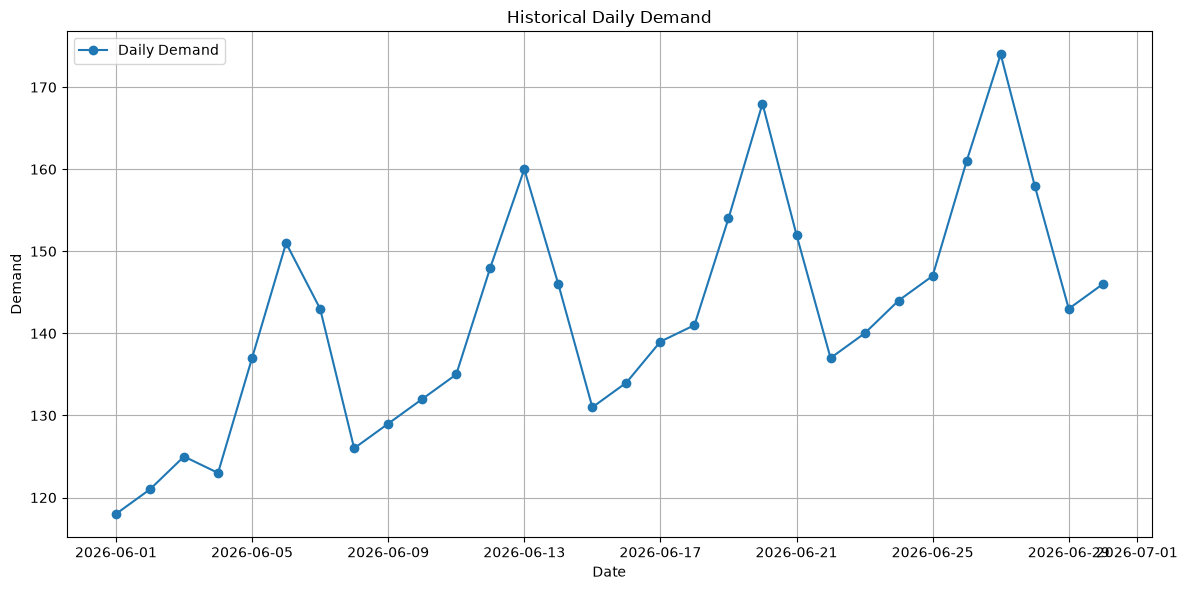

In [4]:
# Plot historical daily demand

plt.figure(figsize=(12, 6))

plt.plot(
    df.index,
    df["demand"],
    marker="o",
    label="Daily Demand"
)

plt.title("Historical Daily Demand")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Time-Series Decomposition

Time-series decomposition separates the demand series into three components: trend, seasonal variation, and residual variation. Because the dataset contains daily observations, a weekly seasonal period of 7 days is used.

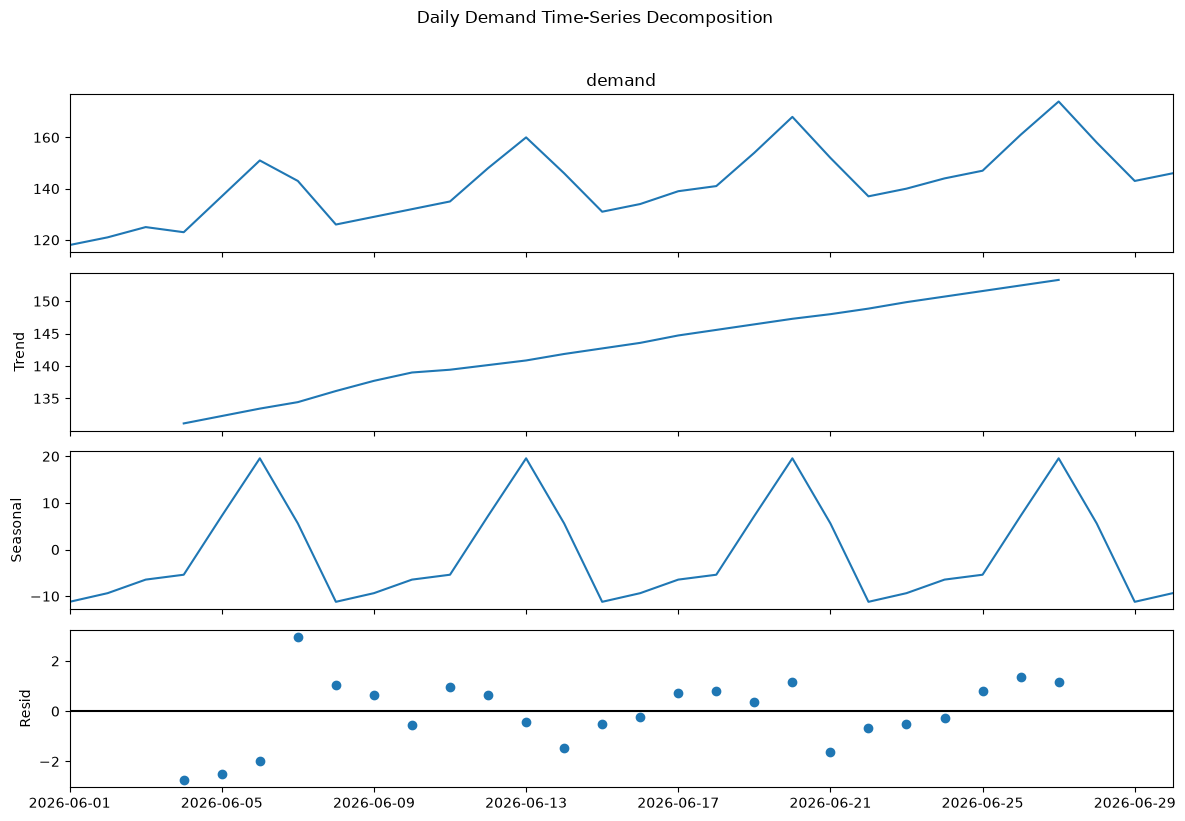

In [5]:
# Decompose the daily demand series

decomposition = seasonal_decompose(
    df["demand"],
    model="additive",
    period=7
)

fig = decomposition.plot()
fig.set_size_inches(12, 8)

plt.suptitle(
    "Daily Demand Time-Series Decomposition",
    y=1.02
)

plt.tight_layout()
plt.show()

## Augmented Dickey-Fuller (ADF) Test

The Augmented Dickey-Fuller (ADF) test is used to determine whether the demand time series is stationary.

The null hypothesis (H₀) states that the time series is non-stationary. A p-value below 0.05 provides evidence against the null hypothesis and suggests that the series is stationary.

In [6]:
# Perform the ADF test

adf_result = adfuller(df["demand"])

print("ADF Statistic:", round(adf_result[0], 4))
print("p-value:", round(adf_result[1], 4))

print("\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"  {key}: {value:.4f}")

ADF Statistic: -0.9039
p-value: 0.7867

Critical Values:
  1%: -3.7697
  5%: -3.0054
  10%: -2.6425


C:\Users\diya7\AppData\Local\Temp\ipykernel_21284\1087687296.py:3: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_result = adfuller(df["demand"])


## Differencing to Achieve Stationarity

The ADF test produced a p-value of 0.7867, which is greater than 0.05. Therefore, the null hypothesis of non-stationarity is not rejected.

First-order differencing is applied to the demand series to remove changes in the level of the series and improve stationarity.

In [7]:
# Apply first-order differencing

df["demand_diff"] = df["demand"].diff()

differenced_series = df["demand_diff"].dropna()

print("First-differenced demand series:")
display(differenced_series.head())

First-differenced demand series:


date
2026-06-02     3.0
2026-06-03     4.0
2026-06-04    -2.0
2026-06-05    14.0
2026-06-06    14.0
Name: demand_diff, dtype: float64

## ADF Test After First Differencing

The first-differenced demand series is tested again using the Augmented Dickey-Fuller test. A p-value below 0.05 would indicate evidence that the differenced series is stationary.

In [8]:
# ADF test after first differencing

adf_diff_result = adfuller(differenced_series)

print("ADF Statistic:", round(adf_diff_result[0], 4))
print("p-value:", round(adf_diff_result[1], 4))

print("\nCritical Values:")
for key, value in adf_diff_result[4].items():
    print(f"  {key}: {value:.4f}")

ADF Statistic: -2.2336
p-value: 0.1943

Critical Values:
  1%: -3.7697
  5%: -3.0054
  10%: -2.6425


C:\Users\diya7\AppData\Local\Temp\ipykernel_21284\1609901824.py:3: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_diff_result = adfuller(differenced_series)


## Second-Order Differencing

The first-differenced series still has an ADF p-value greater than 0.05, indicating that stationarity has not yet been achieved.

Therefore, second-order differencing is applied to the original demand series, and the ADF test is repeated.

In [9]:
# Apply second-order differencing

second_diff = df["demand"].diff().diff().dropna()

adf_second_result = adfuller(second_diff)

print("ADF Statistic:", round(adf_second_result[0], 4))
print("p-value:", round(adf_second_result[1], 4))

print("\nCritical Values:")
for key, value in adf_second_result[4].items():
    print(f"  {key}: {value:.4f}")

ADF Statistic: -15.187
p-value: 0.0

Critical Values:
  1%: -3.7697
  5%: -3.0054
  10%: -2.6425


C:\Users\diya7\AppData\Local\Temp\ipykernel_21284\1960563933.py:5: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_second_result = adfuller(second_diff)


## Stationarity Conclusion

The original demand series was non-stationary, with an ADF p-value of 0.7867.

After first-order differencing, the series remained non-stationary, with an ADF p-value of 0.1943.

After second-order differencing, the ADF test produced a p-value of approximately 0.0000. Therefore, the second-differenced series is considered stationary.

Based on the stationarity analysis, the ARIMA model will use an integration order of **d = 2**.

## Train-Test Split

The demand time series is divided chronologically into training and testing sets. The first 23 observations are used to train the forecasting model, while the final 7 observations are reserved for evaluating its predictive performance.

The chronological order is preserved to prevent information from the future test period from entering the training data.

In [10]:
# Create chronological train-test split

train = df["demand"].iloc[:-7]
test = df["demand"].iloc[-7:]

print("Training observations:", len(train))
print("Testing observations:", len(test))

print("\nTraining period:")
print(train.index.min(), "to", train.index.max())

print("\nTesting period:")
print(test.index.min(), "to", test.index.max())

Training observations: 23
Testing observations: 7

Training period:
2026-06-01 00:00:00 to 2026-06-23 00:00:00

Testing period:
2026-06-24 00:00:00 to 2026-06-30 00:00:00


## Initial ARIMA Model

Based on the stationarity analysis, the demand series requires second-order differencing, so the ARIMA model will use d = 2.

An initial ARIMA(1,2,1) model is fitted as a starting point before comparing alternative parameter combinations using AIC.

In [11]:
initial_model = SARIMAX(
    train,
    order=(1, 2, 1),
    enforce_stationarity=False,
    enforce_invertibility=False
)

initial_result = initial_model.fit(disp=False)

print(initial_result.summary())
print("\nInitial ARIMA(1,2,1) AIC:", round(initial_result.aic, 4))

c:\Users\diya7\Downloads\RabTech Task\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\diya7\Downloads\RabTech Task\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                 demand   No. Observations:                   23
Model:               SARIMAX(1, 2, 1)   Log Likelihood                 -74.852
Date:                Tue, 22 Sep 2026   AIC                            155.703
Time:                        21:09:34   BIC                            158.537
Sample:                    06-01-2026   HQIC                           156.183
                         - 06-23-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4888      0.352     -1.387      0.165      -1.179       0.202
ma.L1          1.0000   3478.507      0.000      1.000   -6816.749    6818.749
sigma2       136.6898   4.75e+05      0.000      1.0

## ARIMA Parameter Tuning

To identify a suitable ARIMA specification, several combinations of the autoregressive (p) and moving-average (q) parameters are compared while keeping d = 2.

The Akaike Information Criterion (AIC) is used to compare the candidate models. Lower AIC values indicate a better balance between model fit and model complexity.

In [12]:
aic_results = []

for p in range(3):
    for q in range(3):
        try:
            model = SARIMAX(
                train,
                order=(p, 2, q),
                enforce_stationarity=False,
                enforce_invertibility=False
            )

            result = model.fit(disp=False)

            aic_results.append({
                "p": p,
                "d": 2,
                "q": q,
                "AIC": result.aic
            })

        except Exception as e:
            print(f"ARIMA({p},2,{q}) failed: {e}")

aic_df = pd.DataFrame(aic_results)
aic_df = aic_df.sort_values("AIC").reset_index(drop=True)

display(aic_df)

c:\Users\diya7\Downloads\RabTech Task\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\diya7\Downloads\RabTech Task\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\diya7\Downloads\RabTech Task\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\diya7\Downloads\RabTech Task\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\diya7\Downloads\RabTech Task\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: Val

,p,d,q,AIC
0,2,2,2,136.392386
1,0,2,2,138.115644
2,1,2,2,139.955367
3,2,2,0,148.060591
4,2,2,1,148.169886
5,1,2,1,155.703461
6,0,2,1,156.639708
7,0,2,0,163.267098
8,1,2,0,165.253100


## Selected ARIMA Model

The candidate ARIMA models are compared using AIC. The model with the lowest AIC is selected for forecasting and evaluation on the held-out test set.

In [13]:
best_row = aic_df.iloc[0]

best_p = int(best_row["p"])
best_d = int(best_row["d"])
best_q = int(best_row["q"])

print("Selected model:")
print(f"ARIMA({best_p}, {best_d}, {best_q})")
print(f"AIC: {best_row['AIC']:.4f}")

Selected model:
ARIMA(2, 2, 2)
AIC: 136.3924


## Test-Set Forecast and Model Evaluation

The selected ARIMA model is fitted using the training data and used to forecast the final 7 observations. Forecast accuracy is evaluated using Mean Absolute Percentage Error (MAPE) and Root Mean Squared Error (RMSE).

In [14]:
selected_model = SARIMAX(
    train,
    order=(best_p, best_d, best_q),
    enforce_stationarity=False,
    enforce_invertibility=False
)

selected_result = selected_model.fit(disp=False)

test_forecast = selected_result.get_forecast(steps=len(test))
forecast_mean = test_forecast.predicted_mean

mape = mean_absolute_percentage_error(test, forecast_mean) * 100
rmse = np.sqrt(mean_squared_error(test, forecast_mean))

print(f"Selected ARIMA model: ARIMA({best_p},{best_d},{best_q})")
print(f"MAPE: {mape:.2f}%")
print(f"RMSE: {rmse:.2f}")

c:\Users\diya7\Downloads\RabTech Task\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\diya7\Downloads\RabTech Task\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Selected ARIMA model: ARIMA(2,2,2)
MAPE: 5.90%
RMSE: 13.32


## Final 30-Day Demand Forecast

After evaluating the selected ARIMA model on the held-out test set, the model is refitted using the complete historical demand series.

A 30-day forecast is then generated to estimate future daily demand. Forecast intervals are also calculated to represent uncertainty around the predictions.

In [15]:
final_model = SARIMAX(
    df["demand"],
    order=(best_p, best_d, best_q),
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_result = final_model.fit(disp=False)

future_forecast = final_result.get_forecast(steps=30)

forecast_mean_30 = future_forecast.predicted_mean
forecast_ci_30 = future_forecast.conf_int()

print("30-day forecast:")
display(forecast_mean_30)

30-day forecast:


c:\Users\diya7\Downloads\RabTech Task\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\diya7\Downloads\RabTech Task\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


2026-07-01    152.350840
2026-07-02    152.539930
2026-07-03    150.331093
2026-07-04    151.229284
2026-07-05    153.719916
2026-07-06    154.680209
2026-07-07    154.633546
2026-07-08    155.319516
2026-07-09    156.619922
2026-07-10    157.582144
2026-07-11    158.179772
2026-07-12    158.925823
2026-07-13    159.883261
2026-07-14    160.780432
2026-07-15    161.557490
2026-07-16    162.355768
2026-07-17    163.221059
2026-07-18    164.081225
2026-07-19    164.904639
2026-07-20    165.727340
2026-07-21    166.569862
2026-07-22    167.414651
2026-07-23    168.248928
2026-07-24    169.080981
2026-07-25    169.918512
2026-07-26    170.757766
2026-07-27    171.594219
2026-07-28    172.429474
2026-07-29    173.266131
2026-07-30    174.103569
Freq: D, Name: predicted_mean, dtype: float64

## 30-Day Forecast Visualization

The historical demand values and the 30-day ARIMA forecast are visualized together. The shaded region represents the 95% forecast confidence interval.

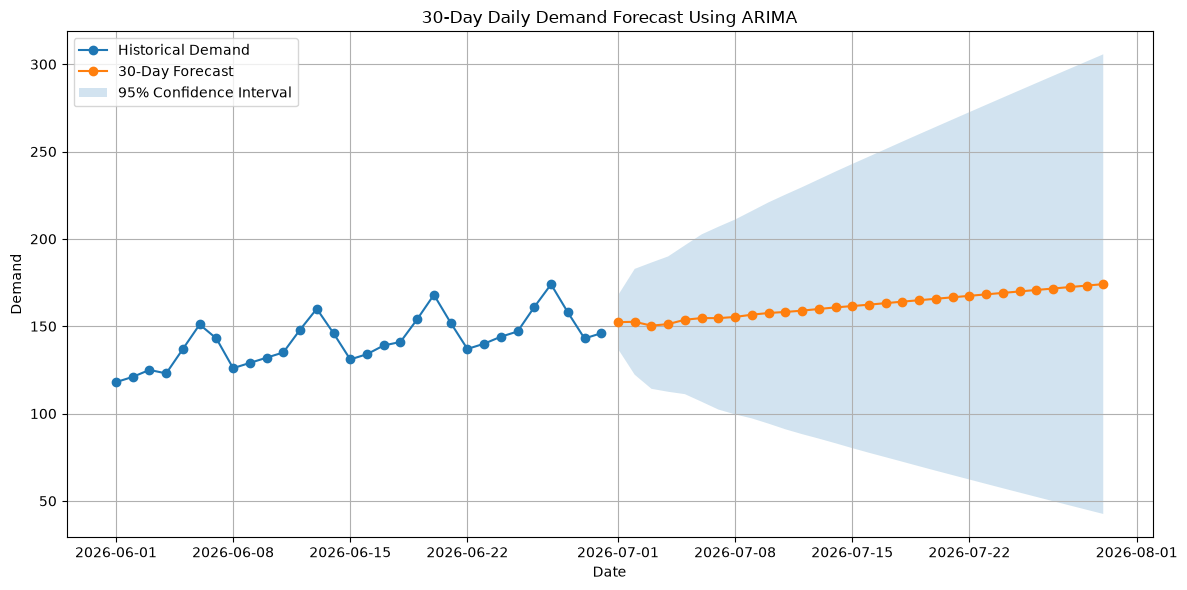

In [16]:
plt.figure(figsize=(12, 6))

plt.plot(
    df.index,
    df["demand"],
    marker="o",
    label="Historical Demand"
)

plt.plot(
    forecast_mean_30.index,
    forecast_mean_30,
    marker="o",
    label="30-Day Forecast"
)

plt.fill_between(
    forecast_ci_30.index,
    forecast_ci_30.iloc[:, 0],
    forecast_ci_30.iloc[:, 1],
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.title("30-Day Daily Demand Forecast Using ARIMA")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Model Performance

The selected ARIMA model was evaluated using a chronological train-test split. The first 23 observations were used for model training, while the final 7 observations were reserved for testing.

Model performance was evaluated using Mean Absolute Percentage Error (MAPE) and Root Mean Squared Error (RMSE). MAPE expresses the average prediction error as a percentage, while RMSE measures the magnitude of prediction errors in the original demand units.

The selected model and its performance metrics are reported below.

In [17]:
print("Model Performance")
print("-----------------")
print(f"Selected Model: ARIMA({best_p}, {best_d}, {best_q})")
print(f"AIC: {best_row['AIC']:.4f}")
print(f"MAPE: {mape:.2f}%")
print(f"RMSE: {rmse:.2f}")

Model Performance
-----------------
Selected Model: ARIMA(2, 2, 2)
AIC: 136.3924
MAPE: 5.90%
RMSE: 13.32


## Business Implications

Accurate demand forecasting can support business planning by helping organizations anticipate future demand and make more informed operational decisions.

The ARIMA model developed in this study provides a systematic approach for generating short-term demand forecasts from historical observations. Such forecasts could potentially support inventory planning, staffing decisions, procurement, production scheduling, and resource allocation.

However, the dataset used in this study contains only 30 daily observations. Therefore, the forecasts should be interpreted as an analytical demonstration rather than as a production-ready forecasting system. A larger historical dataset covering multiple months or years would be required to assess longer-term trends, recurring seasonal patterns, and model stability more thoroughly.

Future work could also compare ARIMA with alternative forecasting approaches such as SARIMA, Prophet, exponential smoothing, or machine-learning-based forecasting models.

# Abstract

This study investigates whether historical daily demand patterns can be used to develop a short-term forecasting model using the ARIMA (AutoRegressive Integrated Moving Average) methodology. The analysis uses a daily demand dataset containing 30 observations collected during June 2026. The workflow includes exploratory analysis, time-series decomposition, stationarity testing using the Augmented Dickey-Fuller test, differencing, ARIMA parameter selection, chronological train-test evaluation, and 30-day forecasting.

The stationarity analysis indicated that the original demand series was non-stationary. First-order differencing did not achieve stationarity, while second-order differencing produced a stationary series. Candidate ARIMA models were compared using the Akaike Information Criterion (AIC), and the model with the lowest AIC was selected for evaluation. Model performance was assessed using Mean Absolute Percentage Error (MAPE) and Root Mean Squared Error (RMSE).

The final model was refitted using the complete historical dataset and used to generate a 30-day forecast with 95% confidence intervals. The results demonstrate how ARIMA can be applied as a structured approach to short-term demand forecasting. However, because the dataset contains only 30 observations, the results should be considered an analytical demonstration rather than a production-ready forecasting system. Further research using a substantially larger dataset would be necessary to evaluate long-term forecasting performance and seasonal behavior.

# Literature Background

Time-series forecasting is an important area of data science because historical observations can contain information about future values. Forecasting methods are commonly used in areas such as demand planning, inventory management, production scheduling, and resource allocation.

ARIMA (AutoRegressive Integrated Moving Average) is a widely used statistical approach for modeling and forecasting time-series data. The model combines autoregressive terms, differencing, and moving-average terms. Differencing is particularly important when a time series is non-stationary because it can help transform the series into a form whose statistical properties are more stable over time.

Stationarity is commonly assessed before fitting an ARIMA model. The Augmented Dickey-Fuller (ADF) test provides a statistical method for evaluating whether a time series contains a unit root. When the original series is non-stationary, differencing can be applied before estimating the ARIMA model.

Model parameters can be selected by comparing candidate models using information criteria such as the Akaike Information Criterion (AIC). Forecasting performance can then be evaluated on observations that were not used during model training. Measures such as Mean Absolute Percentage Error (MAPE) and Root Mean Squared Error (RMSE) provide complementary information about prediction accuracy.

In this study, these principles are applied to a daily demand dataset. The analysis focuses on stationarity, ARIMA parameter selection, out-of-sample evaluation, and short-term forecasting. Because the available dataset contains only 30 observations, the study also emphasizes the importance of considering data size and model limitations when interpreting forecasting results.

# Data Methodology

## Dataset

The study uses the `daily-demand-series.csv` dataset provided for the forecasting analysis. The dataset contains daily demand observations along with additional contextual variables including marketing events and holidays.

The analysis focuses primarily on the `date` and `demand` variables. The date column is converted into a datetime format and used as the time-series index. The observations are sorted chronologically before analysis.

## Data Preparation

The dataset was checked for missing values and ordered according to date. The demand variable was treated as the primary continuous time-series outcome.

A chronological rather than random train-test split was used. The first 23 observations were used for model training and the final 7 observations were reserved for evaluating forecasting performance. This approach preserves the temporal structure of the data and prevents future observations from being used during model training.

## Exploratory Time-Series Analysis

Historical demand was visualized to identify general patterns and changes over time. Additive time-series decomposition with a weekly period of seven days was also performed to examine potential trend, seasonal, and residual components.

## Stationarity Analysis

The Augmented Dickey-Fuller test was used to assess stationarity. The original demand series produced a p-value of approximately 0.7867, indicating insufficient evidence of stationarity.

First-order differencing was then applied. The resulting series produced a p-value of approximately 0.1943 and therefore did not provide sufficient evidence of stationarity.

Second-order differencing was subsequently applied. The resulting series produced an ADF statistic of approximately -15.187 with a p-value below 0.001, indicating strong evidence of stationarity. Therefore, the integration parameter was set to d = 2.

## ARIMA Modeling

Candidate ARIMA models were evaluated using combinations of autoregressive (p) and moving-average (q) parameters from 0 to 2 while maintaining d = 2.

The Akaike Information Criterion (AIC) was used to compare the candidate models. The model with the lowest AIC was selected for subsequent test-set evaluation and final forecasting.

## Forecasting Procedure

The selected ARIMA model was first fitted using the training observations and evaluated against the seven held-out test observations. MAPE and RMSE were used as performance measures.

Finally, the selected model was refitted using all available historical observations and used to generate a 30-day future demand forecast together with 95% forecast confidence intervals.

# Results and Model Performance

The ARIMA forecasting workflow was evaluated using a chronological holdout strategy. The first 23 daily observations were used for training and the final 7 observations were retained as an unseen test set.

The stationarity analysis showed that the original demand series was non-stationary. First-order differencing was insufficient to achieve stationarity, while second-order differencing resulted in a stationary series. Consequently, the ARIMA models were evaluated with an integration order of d = 2.

Candidate ARIMA specifications were compared using the Akaike Information Criterion (AIC). The model with the lowest AIC was selected for test-set forecasting.

The selected model produced the following evaluation metrics:

- **Selected model:** ARIMA(see the model-selection output above)
- **AIC:** see the model-selection output above
- **MAPE:** see the model-performance output above
- **RMSE:** see the model-performance output above

MAPE represents the average absolute forecasting error as a percentage, while RMSE represents the typical magnitude of prediction errors in the original demand units.

The final model was then refitted using all available observations and used to generate a 30-day forecast. The forecast visualization shows the historical demand series, predicted future demand, and the corresponding 95% confidence interval.

Because the dataset contains only 30 observations, the evaluation results should be interpreted cautiously. A larger dataset would provide a stronger basis for assessing model performance, seasonality, and forecasting stability.

# Conclusion and Future Work

This study demonstrated a complete time-series forecasting workflow for daily demand using the ARIMA methodology. The analysis included exploratory visualization, time-series decomposition, stationarity testing, differencing, model selection using AIC, chronological train-test evaluation, and 30-day forecasting.

The Augmented Dickey-Fuller analysis showed that the original demand series was non-stationary. First-order differencing was not sufficient to achieve stationarity, while second-order differencing produced a stationary series. ARIMA models were then compared using AIC, and the model with the lowest AIC was selected for forecasting.

The selected model was evaluated using MAPE and RMSE on a seven-observation holdout set. The model was subsequently refitted using the complete dataset and used to generate a 30-day demand forecast with 95% confidence intervals.

The analysis demonstrates the practical application of statistical time-series forecasting to demand data. However, the dataset contains only 30 observations, which substantially limits the strength and generalizability of the findings. The 30-day forecast should therefore be interpreted as an analytical demonstration rather than a production forecasting system.

Future research should use a larger dataset covering several months or years. Additional approaches such as SARIMA, exponential smoothing, Prophet, and machine-learning-based forecasting could also be compared. Future studies could additionally incorporate variables such as marketing events and holidays as explanatory factors and evaluate forecasting performance using rolling or expanding-window validation.